# Customer Churn Predictor
In this notebook, we will:
- Load and explore the Telco Customer Churn dataset, handling missing and inconsistent values.
- Build and train a Neural Network to predict customer churn.
- Evaluate model performance with precision, recall, F1-score, and confusion matrix.
- Save model artifacts (trained model and scaler) for deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras

## Loading Dataset

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

### Drop irrelevant column

In [4]:
df.drop(columns=['customerID'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


From the data info we found out that the TotalCharges column is a string when it should be a float

### Removing missing TotalCharges then transforming it to float

In [6]:
df = df[df['TotalCharges'] != ' ']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

## Exploratory Data Analysis (EDA)

### Tenure vs Churn

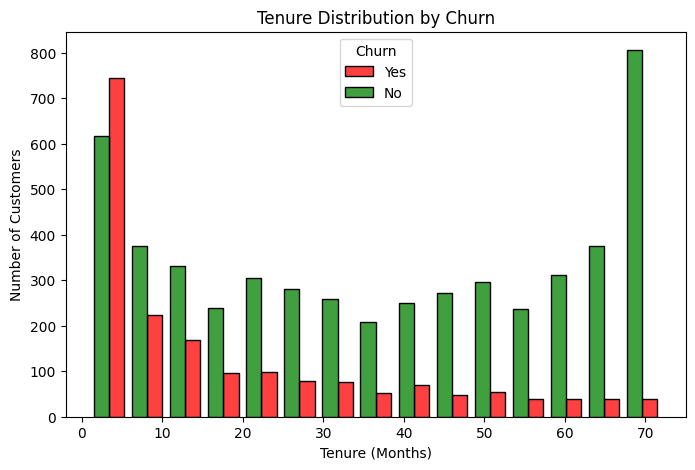

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='dodge', shrink=0.8, palette={'No':'green', 'Yes':'red'})
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.show()

### Monthly Charges vs Churn

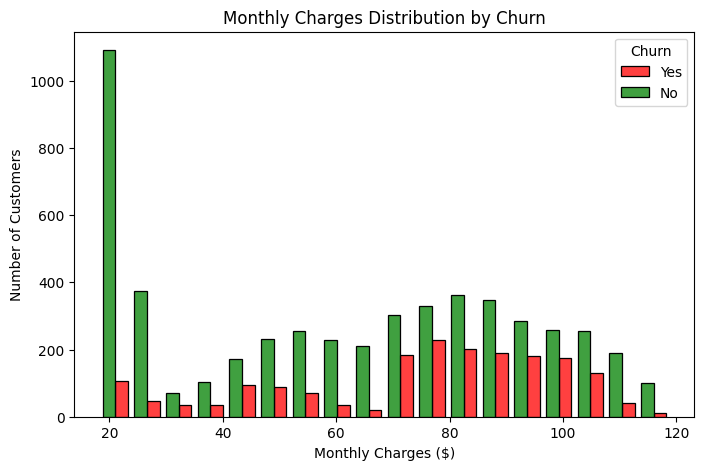

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='dodge', shrink=0.8, palette={'No':'green', 'Yes':'red'})
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Yes', 'No'])
plt.show()

## Encoding Categorical Variables

In [9]:
for columns in df:
    if df[columns].dtype == 'object':
        print(f'{columns}: {df[columns].unique()}')

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [10]:
df.replace('No phone service', 'No', inplace=True)
df.replace('No internet service', 'No', inplace=True)
df.replace({'Yes': 1, 'No': 0}, inplace=True)
df.replace({'Female': 1, 'Male': 0}, inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_15424\3524861413.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes': 1, 'No': 0}, inplace=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_15424\3524861413.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Female': 1, 'Male': 0}, inplace=True)


### One-Hot Encoding

In [11]:
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=categorical_cols)

## Feature Scaling

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

## Split Train and Test Data

In [13]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Building Neural Network

In [14]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')

## Training Model

In [15]:
# Compute class weights to handle class imbalance
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

model.fit(X_train, y_train, epochs=50, class_weight=dict(enumerate(weights)))

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - loss: 0.5552
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 0.4931
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 0.4837
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 0.4806
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 0.4787
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.4754
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.4737
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.4720
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 0.4712
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.4682
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 0.4679
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - loss: 0.4654
Epoch 13/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4636  
Epoch 14/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4628
Epoch 15/50
176/176 ━━━━━━━━━━━

## Model Evaluation

### Classification Report

In [16]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.75      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.78      0.73      0.75      1407



### Confusion Matrix

Text(45.722222222222214, 0.5, 'True')

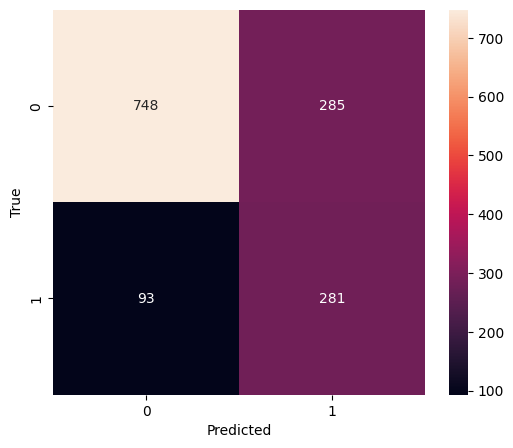

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')

## Exporting the Model

In [18]:
model.save("../models/final_model.keras")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']